In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/ankushpanjiyar/quark-gluon/quark-gluon_data-set_n139306.hdf5


In [3]:
import h5py
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm

from sklearn.metrics import accuracy_score, roc_auc_score

from torch_geometric.data import Dataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GraphConv, global_mean_pool

In [4]:
file_path = "/kaggle/input/datasets/ankushpanjiyar/quark-gluon/quark-gluon_data-set_n139306.hdf5"
f = h5py.File(file_path, "r")

images = f["X_jets"]     # shape: (N, 125, 125, 3)
labels = f["y"][:]       # 0 = quark, 1 = gluon

In [5]:
def image_to_pointcloud(img):

    mask = (img.sum(axis=-1) > 0)

    ys, xs = np.where(mask)

    pixel_vals = img[ys, xs]

    # normalize intensity
    pixel_vals = pixel_vals / (pixel_vals.max(axis=0) + 1e-8)

    xs_norm = (xs / 124) * 2 - 1
    ys_norm = (ys / 124) * 2 - 1

    node_feats = np.column_stack([xs_norm, ys_norm, pixel_vals])

    node_pos = np.column_stack([xs_norm, ys_norm])

    return node_feats.astype(np.float32), node_pos.astype(np.float32)

In [6]:
def build_knn_graph(pos, k=16):

    num_nodes = pos.size(0)

    dist = torch.cdist(pos, pos)

    knn_idx = dist.topk(k=k+1, largest=False).indices[:,1:]

    src = torch.arange(num_nodes).unsqueeze(1).repeat(1,k).flatten()
    dst = knn_idx.flatten()

    edge_index = torch.stack([src, dst], dim=0)

    return edge_index

In [7]:
class JetGraphDataset(Dataset):

    def __init__(self, images, labels):
        super().__init__()
        self.images = images
        self.labels = labels
        self.n = images.shape[0]

    def len(self):
        return self.n

    def get(self, idx):

        img = self.images[idx]
        label = self.labels[idx]

        node_feats, node_pos = image_to_pointcloud(img)

        x = torch.tensor(node_feats, dtype=torch.float32)
        pos = torch.tensor(node_pos, dtype=torch.float32)

        y = torch.tensor([label], dtype=torch.float32)

        edge_index = build_knn_graph(pos, k=16)

        return Data(x=x, pos=pos, edge_index=edge_index, y=y)

In [8]:
train_size = 30000
val_size = 5000

train_dataset = JetGraphDataset(images[:train_size], labels[:train_size])

val_dataset = JetGraphDataset(
    images[train_size:train_size+val_size],
    labels[train_size:train_size+val_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [9]:
class JetGNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = GraphConv(5,64)
        self.conv2 = GraphConv(64,64)

        self.lin1 = nn.Linear(64,32)
        self.lin2 = nn.Linear(32,1)

    def forward(self, x, edge_index, batch):

        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))

        x = global_mean_pool(x, batch)

        x = torch.relu(self.lin1(x))
        x = self.lin2(x)

        return x.view(-1)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = JetGNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = nn.BCEWithLogitsLoss()

EPOCHS = 15

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for batch in tqdm(train_loader):

        batch = batch.to(device)

        optimizer.zero_grad()

        out = model(batch.x, batch.edge_index, batch.batch)

        loss = criterion(out, batch.y.float())

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch+1, "Loss", total_loss/len(train_loader))

100%|██████████| 938/938 [02:15<00:00,  6.92it/s]


Epoch 1 Loss 0.6835972122800376


100%|██████████| 938/938 [02:13<00:00,  7.02it/s]


Epoch 2 Loss 0.6492723319957505


100%|██████████| 938/938 [02:13<00:00,  7.05it/s]


...

Epoch 13 Loss 0.5805815509133248


100%|██████████| 938/938 [02:14<00:00,  6.96it/s]


Epoch 14 Loss 0.5801405815173314


100%|██████████| 938/938 [02:15<00:00,  6.94it/s]

Epoch 15 Loss 0.5769044827105902


In [13]:
model.eval()

preds = []
true = []

with torch.no_grad():

    for batch in val_loader:

        batch = batch.to(device)

        out = model(batch.x, batch.edge_index, batch.batch)

        prob = torch.sigmoid(out).cpu().numpy()

        preds.extend(prob)

        true.extend(batch.y.cpu().numpy())

preds = np.array(preds)
true = np.array(true)

cls = (preds > 0.5).astype(int)

acc = accuracy_score(true, cls)
auc = roc_auc_score(true, preds)

print("Validation Accuracy:", acc)
print("ROC AUC:", auc)

Validation Accuracy: 0.6942
ROC AUC: 0.7591993380991857


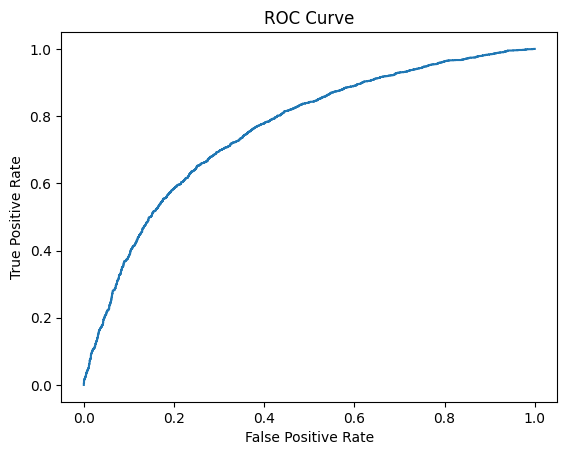

In [14]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(true, preds)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()